In [3]:
from sklearn.datasets import load_wine
import pandas as pd
wine_data=load_wine(as_frame=True)
df=wine_data.frame
print(df)


     alcohol  malic_acid   ash  ...  od280/od315_of_diluted_wines  proline  target
0      14.23        1.71  2.43  ...                          3.92   1065.0       0
1      13.20        1.78  2.14  ...                          3.40   1050.0       0
2      13.16        2.36  2.67  ...                          3.17   1185.0       0
3      14.37        1.95  2.50  ...                          3.45   1480.0       0
4      13.24        2.59  2.87  ...                          2.93    735.0       0
..       ...         ...   ...  ...                           ...      ...     ...
173    13.71        5.65  2.45  ...                          1.74    740.0       2
174    13.40        3.91  2.48  ...                          1.56    750.0       2
175    13.27        4.28  2.26  ...                          1.56    835.0       2
176    13.17        2.59  2.37  ...                          1.62    840.0       2
177    14.13        4.10  2.74  ...                          1.60    560.0       2

[17

In [5]:
# Split and scale the data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X=df.drop('target',axis=1)
y=df['target']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
print("Scaled Training Features:")
print(X_train_scaled)
print("\n")
print("Scaled Testing Features:")
print(X_test_scaled)
print("\n")
print("Splitting and scaling the data is successful")

Scaled Training Features:
[[ 1.66529275 -0.60840587  1.21896194 ... -1.65632857 -0.87940904
  -0.24860607]
 [-0.54952506  2.7515415   1.00331502 ... -0.58463272 -1.25462095
  -0.72992237]
 [-0.74531007 -1.14354109 -0.93750727 ...  0.35845962  0.2462267
  -0.24860607]
 ...
 [ 1.714239   -0.44172441  0.06884503 ...  1.04434496  0.56585166
   2.69572196]
 [-0.35374006 -0.7399965  -0.36244882 ...  0.01551695 -0.74044166
  -0.79631083]
 [-0.78201975  0.06709269  0.35637426 ... -0.67036839  1.09392769
  -0.98551793]]


Scaled Testing Features:
[[ 8.08733375e-01  6.37318741e-01  7.15785791e-01 -1.24128036e+00
   1.06556722e+00  6.46636689e-01  1.02724237e+00 -1.54932094e+00
   8.93605295e-02  1.82522280e-02  1.55169482e-02  1.06613421e+00
   3.65487151e-01]
 [ 1.50621744e+00  1.46195334e+00  2.84491948e-01 -1.66513218e-01
   7.23080697e-01  8.82684015e-01  6.47480801e-01 -5.32234717e-01
  -6.15594759e-01  7.85270273e-02 -3.70293555e-01  1.02444400e+00
   1.14555151e+00]
 [-6.00625639e-02  3.8

In [9]:
# 1. Apply dimensionality reduction
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
X_train_pca=pca.fit_transform(X_train_scaled)
X_test_pca=pca.transform(X_test_scaled)
print("PCA Reduced Training Features:")
print(X_train_pca)
print("\n")
print("PCA Reduced Testing Features:")
print(X_test_pca)
print("\n")
print("Dimensionality reduction using PCA is successful.")

PCA Reduced Training Features:
[[-1.16602698e+00  3.61532732e+00]
 [-3.86261156e+00  4.82177461e-01]
 [ 2.28353786e+00 -1.27503318e+00]
 [-1.67850727e+00  2.49696152e+00]
 [ 1.57284216e+00 -6.88203487e-01]
 [ 2.02555486e-01 -2.22577338e+00]
 [ 8.83338617e-01 -2.00469937e+00]
 [-7.15050214e-01 -2.02557575e-01]
 [-2.31535447e+00  3.50467442e-01]
 [ 2.48181734e+00  1.19480758e+00]
 [ 9.27003335e-01 -2.36914720e+00]
 [-1.10503027e+00 -7.91750104e-01]
 [-2.64179811e+00  3.73566993e-01]
 [ 2.82856352e+00  9.08533324e-01]
 [ 4.68714502e-01 -2.12468019e+00]
 [ 2.70840181e+00  1.53490440e+00]
 [ 1.78020693e+00  8.47127661e-01]
 [-2.75483138e+00  2.13895379e+00]
 [-3.00838158e+00  2.84596615e-01]
 [ 5.08790176e-01 -2.03246235e+00]
 [ 1.36844583e+00 -7.60471135e-01]
 [ 1.38621221e+00  7.05661067e-01]
 [ 8.27658568e-01 -2.30685810e+00]
 [ 2.56156818e+00  3.30885610e-02]
 [-4.19073741e+00  4.09150784e-01]
 [ 1.12473644e+00 -2.47440627e+00]
 [ 2.10180811e+00 -1.53564514e+00]
 [-2.90299543e+00  1.158

In [13]:
# 2. Analyze explained variance ratio
variance_ratio=pca.explained_variance_ratio_
print(f"Explained Variance Ratio:{variance_ratio}")
print(f"Total Information Retained:{((variance_ratio.sum())*100):.2f}%")
print("\n")
print("Analyzing explained variance ratio is successful.")

Explained Variance Ratio:[0.35900066 0.18691934]
Total Information Retained:54.59%


Analyzing explained variance ratio is successful.


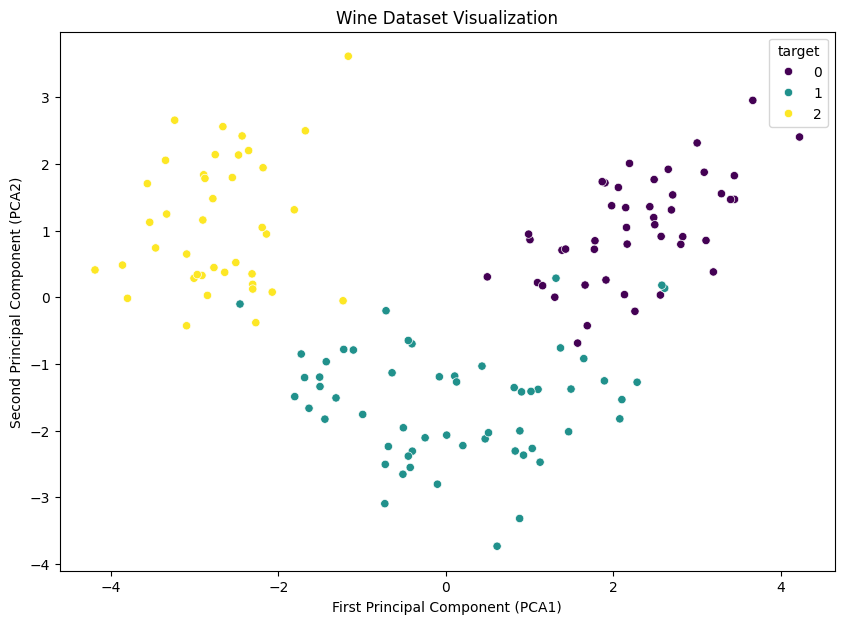

In [16]:
# 3. Visualize data in 2D
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,7))
plt.title("Wine Dataset Visualization")
sns.scatterplot(x=X_train_pca[:,0],y=X_train_pca[:,1],hue=y_train,palette="viridis")
plt.xlabel("First Principal Component (PCA1)")
plt.ylabel("Second Principal Component (PCA2)")
plt.savefig("Wine Data Visualization.png")
plt.show()